In [1]:
import pandas as pd # for uploading the data
import numpy as np # for calculations
import re # for data cleaning
import nltk # for preprocessing
import matplotlib.pyplot as plt # for
from nltk.corpus import stopwords # to remove the unnecesary words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud # To visualize the word

In [9]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [11]:
data={
    "Review":[
        "The movie had an amazing storyline and the actors delivered outstanding performances. I enjoyed every minute of it.",
        "The plot was confusing and the ending was disappointing. I expected much more from this film.",
        "It was an average movie with decent acting and good visuals, but nothing really stood out.",
        "The background music perfectly matched every scene, making the emotional moments unforgettable.",
        "The screenplay was slow and boring, making it difficult to stay interested until the end.",
        "The web series started well but became repetitive after a few episodes. Overall, it was okay.",
        "The lead actor gave a brilliant performance, and the direction was excellent. Highly recommended!",
        "The special effects looked outdated, and the story lacked originality. It was a waste of time.",
        "The movie had a few entertaining moments, but it was neither impressive nor disappointing.",
        "I loved the emotional depth of the characters and the beautiful cinematography."

    ]
}

df=pd.DataFrame(data)
print("Coustomer Reviews Dataset")
print(df.head(5))


Coustomer Reviews Dataset
                                              Review
0  The movie had an amazing storyline and the act...
1  The plot was confusing and the ending was disa...
2  It was an average movie with decent acting and...
3  The background music perfectly matched every s...
4  The screenplay was slow and boring, making it ...


In [12]:
stop_words=set(stopwords.words('english'))

def clean_text(text):

  text=text.lower()

  text=re.sub('[^a-zA-Z]'," ",text)

  words=word_tokenize(text)

  words=[word for word in words if word not in stop_words]
  print('Without stopwords',words)

  cleaned_text=" ".join(words)

  return cleaned_text

df["Cleaned_Review"]=df["Review"].apply(clean_text)

print("\nCleaned Review")
print(df[['Review','Cleaned_Review']])

Without stopwords ['movie', 'amazing', 'storyline', 'actors', 'delivered', 'outstanding', 'performances', 'enjoyed', 'every', 'minute']
Without stopwords ['plot', 'confusing', 'ending', 'disappointing', 'expected', 'much', 'film']
Without stopwords ['average', 'movie', 'decent', 'acting', 'good', 'visuals', 'nothing', 'really', 'stood']
Without stopwords ['background', 'music', 'perfectly', 'matched', 'every', 'scene', 'making', 'emotional', 'moments', 'unforgettable']
Without stopwords ['screenplay', 'slow', 'boring', 'making', 'difficult', 'stay', 'interested', 'end']
Without stopwords ['web', 'series', 'started', 'well', 'became', 'repetitive', 'episodes', 'overall', 'okay']
Without stopwords ['lead', 'actor', 'gave', 'brilliant', 'performance', 'direction', 'excellent', 'highly', 'recommended']
Without stopwords ['special', 'effects', 'looked', 'outdated', 'story', 'lacked', 'originality', 'waste', 'time']
Without stopwords ['movie', 'entertaining', 'moments', 'neither', 'impressiv

In [16]:
sia=SentimentIntensityAnalyzer()
def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound=score['compound']
  if compound >=0.05:
    return "Positive"
  elif compound <=-0.05:
    return "Negative"
  else:
    return "Neutral"

  df['Sentiment']=df['Cleaned_Review'].apply(analyze_sentiment)

  print("\nSentiment Analysis Result")
  print(df[['Review','Sentiment']])

In [17]:
all_words="".join(df['Cleaned_Review'])

word_list=all_words.split()
word_freq=Counter(word_list)

print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))


Top 10 Common Keywords
[('movie', 2), ('every', 2), ('making', 2), ('emotional', 2), ('moments', 2), ('amazing', 1), ('storyline', 1), ('actors', 1), ('delivered', 1), ('outstanding', 1)]


In [15]:
df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)
negative_reviews = df[df['Sentiment'] =='Negative']   # Row filter
negative_words =' '.join(negative_reviews['Cleaned_Review'])

negative_word_list=negative_words.split()
complaint_freq=Counter(negative_word_list)

print("\nMost Common Complaint Keywords")
print(complaint_freq.most_common(10))


Most Common Complaint Keywords
[('plot', 1), ('confusing', 1), ('ending', 1), ('disappointing', 1), ('expected', 1), ('much', 1), ('film', 1), ('screenplay', 1), ('slow', 1), ('boring', 1)]


In [18]:
sentiment_counts=df['Sentiment'].value_counts()
sentiment_counts

,count
Sentiment,
Positive,7
Negative,2
Neutral,1


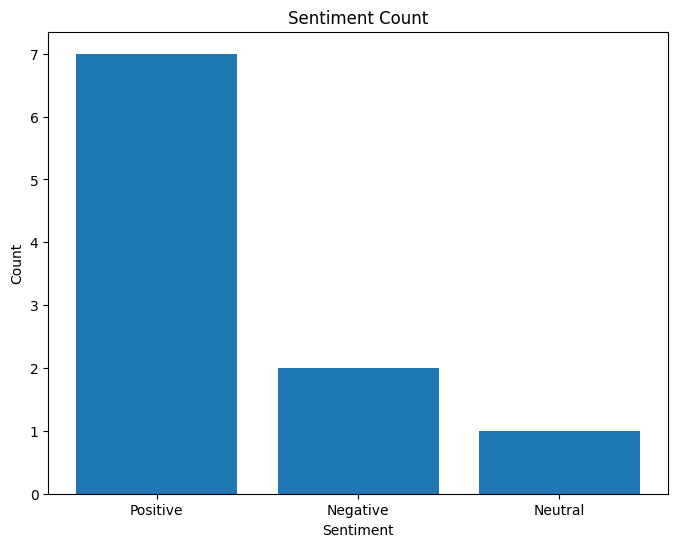

In [19]:
sentiment_counts=df['Sentiment'].value_counts()
plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Count')
plt.show()

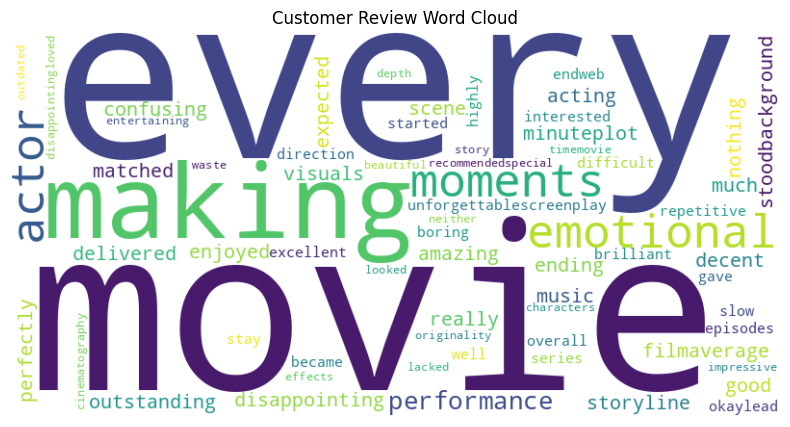

In [20]:
wordcloud=WordCloud(
    width=800,
    height=400,
    background_color='white'
    ).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Customer Review Word Cloud')
plt.show()